===== 데이터 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


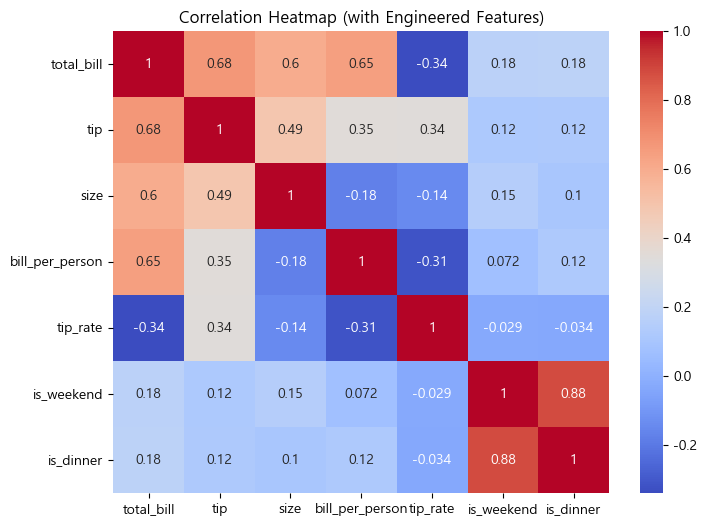


===== 모델 성능 =====
R2 Score: 0.8222
RMSE: 0.4714


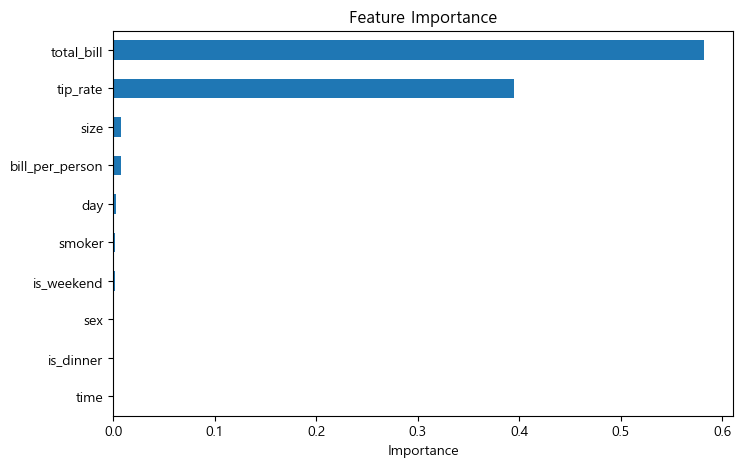

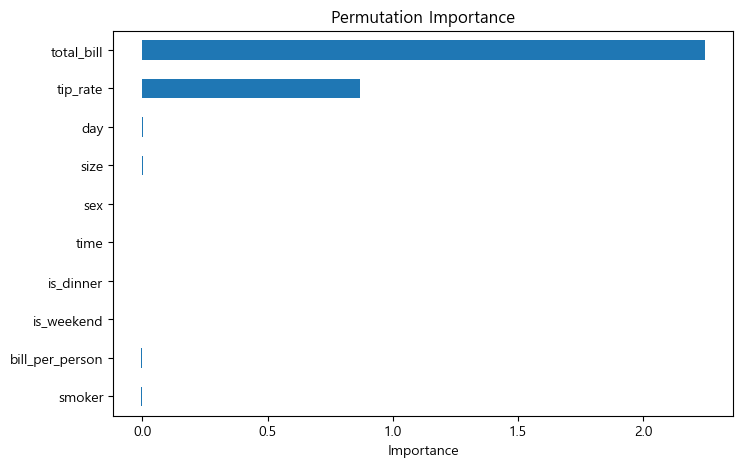

['model/tips_labelencoders02.pkl']

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

import joblib

# 1. 데이터 로드
df = pd.read_csv("dataset/tips.csv")

print("===== 데이터 정보 =====")
print(df.info())

# 2. Feature Engineering (추가된 피처, 파생변수 : 기존에 없던 정보를 새로 만들어 모델 성능을 높이는 작업)
df['bill_per_person'] = df['total_bill'] / df['size']   # 1인당 금액
df['is_weekend'] = df['day'].isin(['Sat','Sun']).astype(int)  # 주말 여부  (True:1, False:0)
df['is_dinner'] = (df['time'] == 'Dinner').astype(int)  # 저녁 여부 (True:1, False:0)
df['tip_rate'] = df['tip'] / df['total_bill']  # 팁 비율

# 3. 히트맵 분석 (수치형 + 파생변수 포함)
plt.figure(figsize=(8,6))

numeric_cols = [
    'total_bill', 'tip', 'size',
    'bill_per_person', 'tip_rate',
    'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (with Engineered Features)")
plt.show()

# 4. 라벨 인코딩
categorical_cols = ['sex', 'smoker', 'day', 'time']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
# 5. Feature/Target X, y 분리
X = df.drop('tip', axis=1)
y = df['tip']

# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 모델 학습 (하이퍼파라미터 튜닝 적용)
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

# 8. 예측 및 평가
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n===== 모델 성능 =====")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

# 10. Permutation Importance
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
)

plt.figure(figsize=(8,5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.xlabel("Importance")
plt.show()

# 11. 모델 저장
joblib.dump(model, "model/tips_model02.pkl")
joblib.dump(encoders, "model/tips_labelencoders02.pkl")